# Livrable Final


## Objectifs

Ce livrable présente un pipeline complet de traitement d'images de légendes en trois étapes :

Classification des images bruitées -> analyse des images dans leur état initial pour établir une référence.

Débruitage -> restauration des images grâce à l'auto-encodeur U-Net pour retrouver leur clarté originale.

Génération de légendes (captioning) -> production automatique de descriptions textuelles à partir des images restaurées.




In [1]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt


I0000 00:00:1780555769.173313   44431 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780555769.506305   44431 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780555771.363868   44431 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import os

# 1. Configuration des dossiers
img_dir = "datasets/final"
if not os.path.exists(img_dir):
    raise FileNotFoundError(f"Dossier '{img_dir}' introuvable.")

# Récupération de TOUTES les images
image_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
if not image_files:
    raise FileNotFoundError(f"Aucune image trouvée dans '{img_dir}'.")
image_paths = [os.path.join(img_dir, f) for f in image_files]

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [300, 300]) # Taille pour l'auto-encodeur (compatible pour plus tard)
    img = tf.cast(img, tf.float32) / 255.0  # Normalisation [0, 1]
    return img

# Création du dataset complet
path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
full_dataset = path_ds.map(load_and_preprocess).batch(16)

# On accumule les images d'origine
all_images_batch = []
for batch in full_dataset:
    all_images_batch.append(batch.numpy())

images_batch = np.concatenate(all_images_batch, axis=0)
print(f"Chargement de {len(images_batch)} images terminé.")

Chargement de 11 images terminé.


W0000 00:00:1780555773.557011   44431 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Étape 1 : Classification initiale sur images bruitées
Nous commençons par charger notre modèle de classification pour analyser les images telles qu'elles sont dans le dossier final (donc avec du bruit). Cela nous permettra de voir la performance du modèle sans correction préalable.

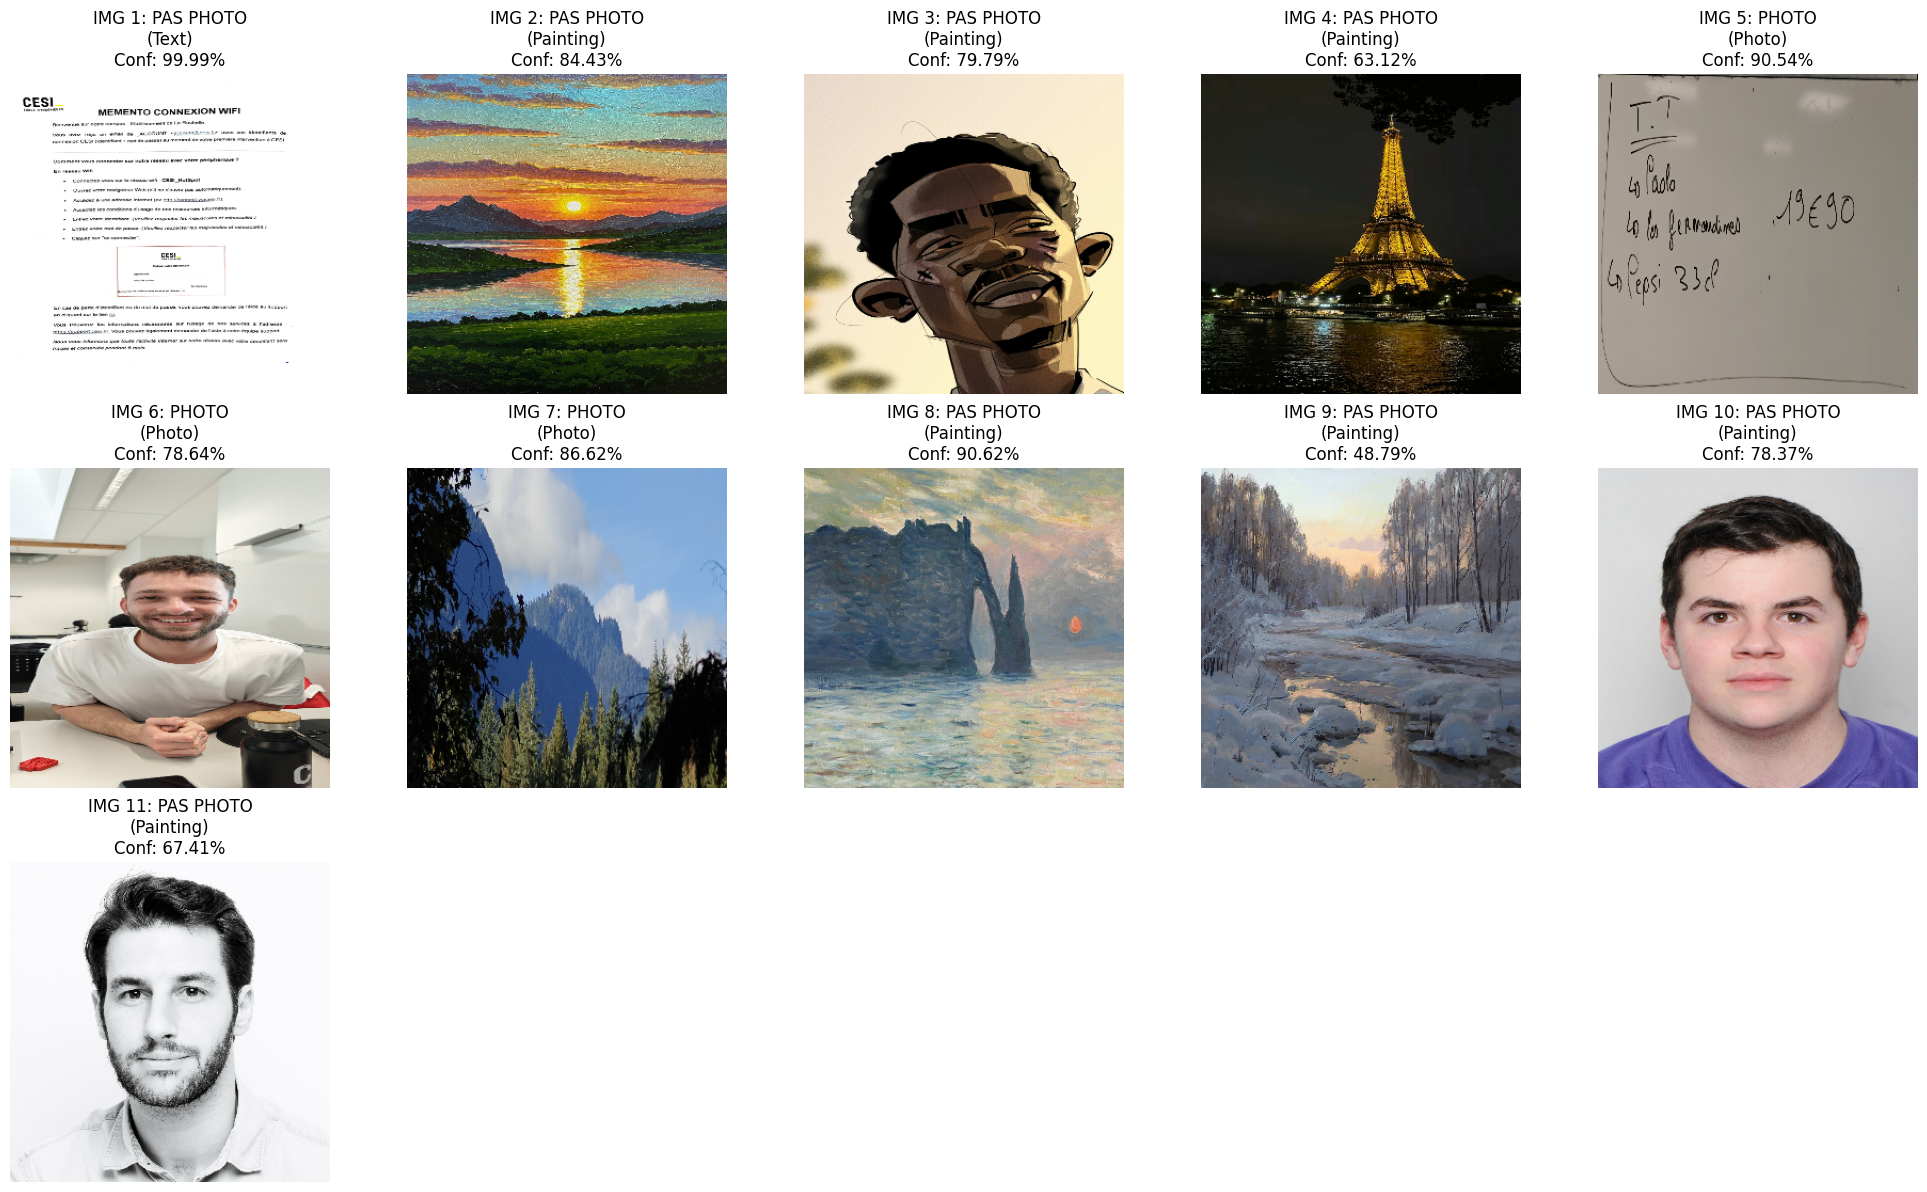


--- Statistiques finales sur 11 images BRUITÉES ---
Photos détectées (sans débruitage) : 3
Confiance moyenne : 78.94%


In [3]:
from tensorflow import keras

# 1. Chargement du modèle de classification amélioré
classifier_model = keras.models.load_model('models/livrable1/improved_model.keras', compile=False)
class_names = ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']

# 2. Adaptation des images d'origine (Echelle 0-255 et Taille 180x180 pour le classifieur)
images_original_255 = images_batch * 255.0
images_original_resized = tf.image.resize(images_original_255, [180, 180])

# 3. Prédiction sur l'original bruité
preds_orig = classifier_model.predict(images_original_resized, verbose=0)
scores_orig = tf.nn.softmax(preds_orig)

# 4. Affichage des images
num_total = len(images_batch)
cols = 5
rows = (num_total + cols - 1) // cols

plt.figure(figsize=(20, 4 * rows))

for i in range(num_total):
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(images_batch[i])
    
    idx_max = np.argmax(scores_orig[i])
    predicted_class = class_names[idx_max]
    confidence = 100 * np.max(scores_orig[i])
    is_photo = "PHOTO" if predicted_class == "Photo" else "PAS PHOTO"
    
    plt.title(f"IMG {i+1}: {is_photo}\n({predicted_class})\nConf: {confidence:.2f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Statistiques globales sur l'original
photo_count_orig = np.sum([class_names[np.argmax(s)] == "Photo" for s in scores_orig])
print(f"\n--- Statistiques finales sur {num_total} images BRUITÉES ---")
print(f"Photos détectées (sans débruitage) : {photo_count_orig}")
print(f"Confiance moyenne : {np.mean(np.max(scores_orig, axis=1))*100:.2f}%")

## Étape 2 : Opération de débruitage
Maintenant que nous avons une première évaluation, nous utilisons notre auto-encodeur performant (U-Net) pour nettoyer ces images bruitées et retrouver la clarté originale.

Débruitage de 11 images en cours...


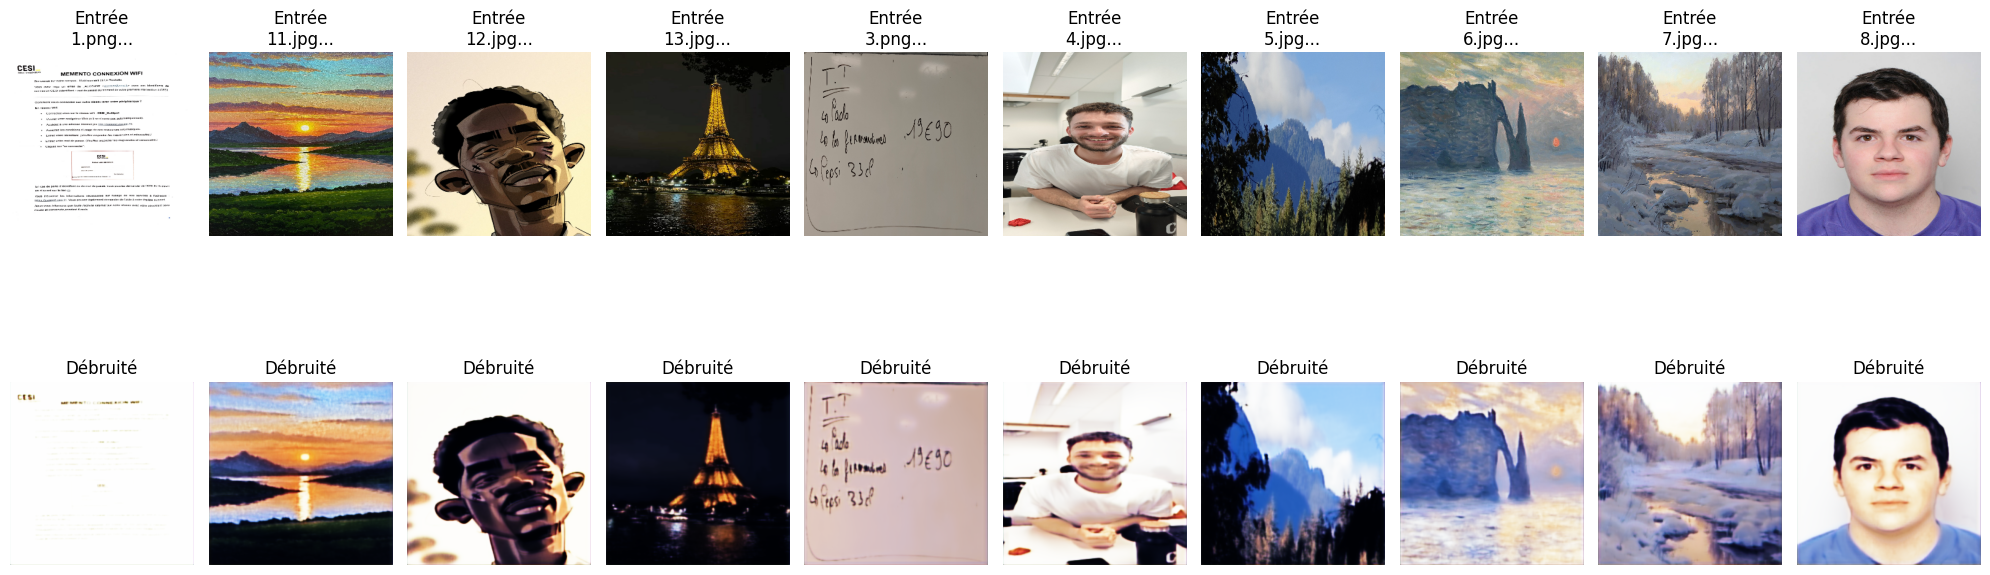

In [4]:
# 1. Chargement du modèle d'auto-encodeur
model_path = "models/livrable2/autoencoder.keras"
if os.path.exists(model_path):
    model_charge = tf.keras.models.load_model(model_path)
else:
    raise FileNotFoundError(f"Modèle introuvable à : {model_path}")

# 2. Prédiction sur TOUT le dataset
all_images_denoised = []

print(f"Débruitage de {len(images_batch)} images en cours...")
for batch in full_dataset:
    denoised = model_charge.predict(batch, verbose=0)
    all_images_denoised.append(denoised)

# On concatène pour avoir le tableau débruité
images_denoised = np.concatenate(all_images_denoised, axis=0)

# 3. Visualisation (on limite l'affichage aux 10 premières)
n_display = min(10, len(images_denoised))
plt.figure(figsize=(20, 8))
for i in range(n_display):
    # Entrée
    ax = plt.subplot(2, n_display, i + 1)
    plt.imshow(images_batch[i])
    plt.title(f"Entrée\n{image_files[i][:10]}...")
    plt.axis("off")

    # Résultat
    ax = plt.subplot(2, n_display, i + 1 + n_display)
    plt.imshow(images_denoised[i])
    plt.title("Débruité")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Étape 3 : Captionning des images